In [1]:
import tensorly as tl
tl.get_backend()

'numpy'

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import plotly.io as pio
pio.renderers.default = 'iframe'


In [4]:
from moabb.paradigms import P300
from moabb.datasets import *


paradigm = P300(resample=48, tmin=0, tmax=0.8)
dataset = BNCI2014_008()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
    return_epochs=True,
    subjects=[1]
)

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning:

warnEpochs <Epochs | 4200 events (all good), 0 – 0.801 s (baseline off), ~52.8 MB, data loaded,
 'Target': 700
 'NonTarget': 3500>



Adding metadata with 3 columns
Adding metadata with 3 columns
4200 matching events found
No baseline correction applied


/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/paradigms/base.py:350: RuntimeWarning:

Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.



In [5]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
import numpy as np
import scipy.stats

X = tl.tensor(epochs.get_data())
X = scipy.stats.zscore(X, axis=0)
y = labels
X.shape

(4200, 8, 39)

In [6]:
from hoda.hoda import HODA

hoda = HODA(
        rank=None,
        max_iter=64,
        tol=1e-6,
        shrinkage='lw',
        obj='tr',
        solver='lanczos',
        toeplitz=None,
        taper=False,
        extra_train_info=True,
        verbose=True,
        random_state=42,
        theta=0.0,
        forward=True       
)


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')

hoda.fit_backward(X,y)
df = pd.DataFrame(hoda.train_info_['backward'])
#df

/vsc-hard-mounts/leuven-data/352/vsc35289/hoda-bci/src/hoda/util.py:26: RuntimeWarning:

k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.

  0%|          | 0/64 [00:00<?, ?it/s]/vsc-hard-mounts/leuven-data/352/vsc35289/hoda-bci/src/hoda/util.py:26: RuntimeWarning:

k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.

Backward HODA model rank=(1, 1):   0%|          | 0/64 [00:00<?, ?it/s]/vsc-hard-mounts/leuven-data/352/vsc35289/hoda-bci/src/hoda/util.py:26: RuntimeWarning:

k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.

/vsc-hard-mounts/leuven-data/352/vsc35289/hoda-bci/src/hoda/util.py:26: RuntimeWarning:

k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.

Backward HODA model rank=(1, 1):   0%|          | 0/64 [00:00<?, ?it/s]/vsc-hard-mounts/leuven-data/352/vsc35289/hoda-bci/src/hoda/util.py:26: RuntimeWarning:

k >= N for N * N square matrix. Attempting to use scipy.linalg.

In [8]:
df['flip'] = (df['iteration']-1)*2+df['mode']
df

,iteration,mode,update,shrinkage,objective,F_tr,F_rt,log_loss,flip
0,1,0,8.233876e-01,0.000913,547898.238699,0.002294,0.000001,0.449926,0
1,1,1,1.042199e+00,0.030839,40758.230610,0.016690,0.000008,0.445972,1
2,2,0,7.981389e-01,0.000796,326442.300915,0.022936,0.000011,0.444275,2
3,2,1,7.704355e-01,0.031286,26370.173545,0.063844,0.000030,0.433189,3
4,3,0,5.016944e-01,0.000895,67817.518450,0.162565,0.000077,0.406985,4
5,3,1,5.166408e-01,0.042978,21566.559471,0.220968,0.000105,0.392115,5
6,4,0,4.737609e-01,0.000936,24226.546130,0.313084,0.000149,0.369897,6
7,4,1,2.335032e-01,0.046046,19369.631203,0.331595,0.000158,0.365516,7
8,5,0,2.610100e-01,0.000949,13404.507734,0.377543,0.000180,0.354921,8
9,5,1,1.335190e-01,0.045315,18791.914766,0.384734,0.000183,0.353234,9


In [9]:
import plotly.express as px

if hoda.extra_train_info:
    fig = px.line(df, x='flip', y='F_tr')
    fig.show()


In [10]:
if hoda.extra_train_info:
    fig = px.line(df, x='flip', y='F_rt')
    fig.show()


In [11]:

px.line(df, x='flip', y='update', log_y=True, color='mode')


In [12]:
px.line(df, x='flip', y='shrinkage', log_y=False, color='mode')

In [13]:
px.line(df, x='flip', y='objective', log_y=True, color='mode')

In [14]:
hoda.fit_forward(X,y)
df = pd.DataFrame(hoda.train_info_['forward'])
df

Forward model :  23%|██▎       | 15/64 [00:00<00:01, 31.13it/s]


,iteration,mode,update,shrinkage,mse,nmse
0,0,0,inf,NaN,0.999745,0.999745
1,0,1,inf,NaN,0.999745,0.999745
2,1,0,1.506493e+00,0.0,0.999166,0.999166
3,1,1,7.510605e-01,0.0,0.998695,0.998695
4,2,0,3.051312e-01,0.0,0.998574,0.998574
5,2,1,1.898958e-01,0.0,0.998522,0.998522
6,3,0,1.145087e-01,0.0,0.998503,0.998503
7,3,1,6.816018e-02,0.0,0.998496,0.998496
8,4,0,4.038414e-02,0.0,0.998494,0.998494
9,4,1,2.388820e-02,0.0,0.998493,0.998493


In [15]:
df['flip'] = (df['iteration']-1)*2+df['mode']
df

,iteration,mode,update,shrinkage,mse,nmse,flip
0,0,0,inf,NaN,0.999745,0.999745,-2
1,0,1,inf,NaN,0.999745,0.999745,-1
2,1,0,1.506493e+00,0.0,0.999166,0.999166,0
3,1,1,7.510605e-01,0.0,0.998695,0.998695,1
4,2,0,3.051312e-01,0.0,0.998574,0.998574,2
5,2,1,1.898958e-01,0.0,0.998522,0.998522,3
6,3,0,1.145087e-01,0.0,0.998503,0.998503,4
7,3,1,6.816018e-02,0.0,0.998496,0.998496,5
8,4,0,4.038414e-02,0.0,0.998494,0.998494,6
9,4,1,2.388820e-02,0.0,0.998493,0.998493,7


In [16]:
px.line(df, x='flip', y='mse', log_y=True)

In [17]:
px.line(df, x='flip', y='update', log_y=True, color='mode')

In [18]:
px.line(df, x='flip', y='shrinkage', log_y=True, color='mode')

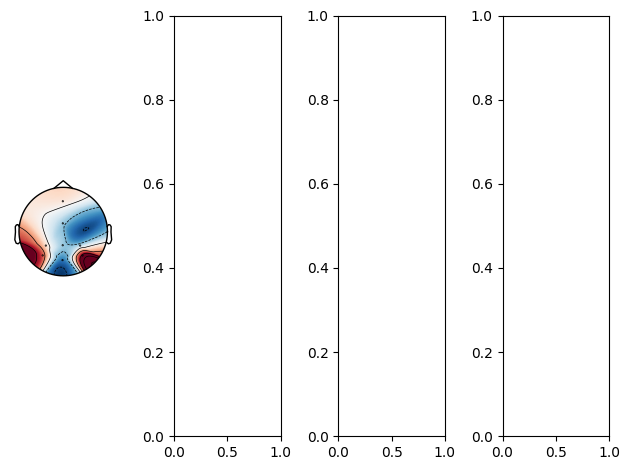

In [19]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl

col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
vmax = float(tl.max(tl.abs(hoda.weights_[0])))
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

In [20]:
from mne.viz import plot_topomap
from plotly.tools import mpl_to_plotly

# TODO spatial weights
df = pd.DataFrame(tl.to_numpy(hoda.weights_[1]))
df['time'] = epochs.times
df = df.melt(id_vars=['time'], var_name='rank', value_name='weight')
px.line(df, x='time', y='weight', facet_col='rank', facet_col_wrap=4)

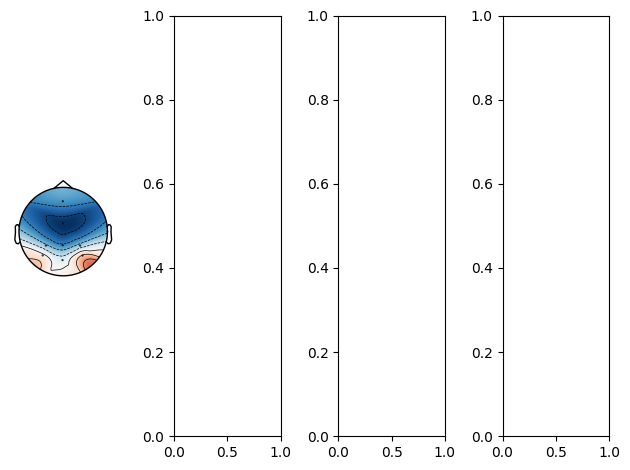

In [21]:

n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
vmax = float(tl.max(tl.abs(A)))
for i in range(hoda.rank_[0]):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])


In [22]:
df = pd.DataFrame(tl.to_numpy(hoda.aps_[1]))
df['time'] = epochs.times
df = df.melt(id_vars=['time'], var_name='rank', value_name='amplitude')
px.line(df, x='time', y='amplitude', facet_col='rank', facet_col_wrap=4)

In [23]:
from sklearn.feature_selection import SelectFpr, SelectFwe, SelectFdr
import numpy as np
from sklearn.preprocessing import StandardScaler

Xt = hoda.transform(X)
xt = tl.to_numpy(tl.unfold(Xt,0))
xt = StandardScaler().fit_transform(xt)

select = SelectFdr(alpha=.05)
xts = select.fit_transform(xt,y)

df = pd.DataFrame({
    'feature': np.arange(xt.shape[-1]),
    'F': select.scores_,
    'p_value': select.pvalues_,
    'significant': select.get_support()
})
df

,feature,F,p_value,significant
0,0,931.355778,6.376834e-185,True


In [24]:
fig = px.bar(df, x='feature', y='F', color='significant', log_y=True)
fig.update_xaxes(type='category', categoryorder='total descending')
fig.show()

In [25]:
from sklearn.manifold import TSNE

x_viz = TSNE(n_components=2).fit_transform(xts)
fig = px.scatter(x=x_viz[:,0], y=x_viz[:,1], color=y)

ValueError: n_components=2 must be between 1 and min(n_samples, n_features)=1 with svd_solver='randomized'

In [30]:
from sklearn.metrics import get_scorer

scorer = get_scorer(paradigm.scoring)
scorer([0,1],[0,1])

TypeError: _BaseScorer.__call__() missing 1 required positional argument: 'y_true'